In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import torchvision.models as models
import matplotlib.pyplot as plt

# Configuration
CSV_PATH = r'cleaned_dataset\new_csv\train_full.csv'
PREPARE_DIR = 'prepare'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 8
EPOCHS = 100
LEARNING_RATE = 1e-4

print(f"Using device: {DEVICE}")

Using device: cuda


In [2]:
class EggSDFDataset(Dataset):
    def __init__(self, df, prepare_dir):
        self.df = df
        self.prepare_dir = prepare_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        base_name = os.path.splitext(row['image_path'])[0]
        
        # 1. Load Input (Resized Partial Mask)
        input_path = os.path.join(self.prepare_dir, 'partial_masks_resized', f"{base_name}.png")
        input_img = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)
        
        # 2. Load Targets (SDF and Weight Map)
        sdf = np.load(os.path.join(self.prepare_dir, 'sdf', f"{base_name}_sdf.npy"))
        weight = np.load(os.path.join(self.prepare_dir, 'weight_maps', f"{base_name}_weight.npy"))
        
        # 3. Load Regression Targets (Normalized)
        l_w_target = np.array([row['length_mm'] / 60.0, row['width_mm'] / 50.0], dtype=np.float32)
        
        # 4. To Tensors
        input_tensor = torch.from_numpy(input_img).float().unsqueeze(0) / 255.0
        sdf_tensor = torch.from_numpy(sdf).float().unsqueeze(0)
        weight_tensor = torch.from_numpy(weight).float().unsqueeze(0)
        reg_tensor = torch.from_numpy(l_w_target).float()

        return input_tensor, sdf_tensor, weight_tensor, reg_tensor

# Load and Split data
df_full = pd.read_csv(CSV_PATH)
train_df, val_df = train_test_split(df_full, test_size=40, random_state=42)

train_loader = DataLoader(EggSDFDataset(train_df, PREPARE_DIR), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(EggSDFDataset(val_df, PREPARE_DIR), batch_size=BATCH_SIZE, shuffle=False)

In [3]:
class EggSDFModel(nn.Module):
    def __init__(self):
        super(EggSDFModel, self).__init__()
        resnet = models.resnet18(pretrained=True)
        
        # Encoder - Includes standard ResNet maxpool for 5 total downsampling steps
        self.encoder0 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False),
            resnet.bn1, 
            resnet.relu,
            resnet.maxpool # Downsamples 512 -> 256 -> 128
        )
        self.encoder1 = resnet.layer1 # 128
        self.encoder2 = resnet.layer2 # 64
        self.encoder3 = resnet.layer3 # 32
        self.encoder4 = resnet.layer4 # 16 (Bottleneck)
        
        # Regression Head
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.reg_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 2) 
        )
        
        # Decoder - 5 upsampling steps (2^5 = 32x) to go from 16 to 512
        self.up4 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2) # 16 -> 32
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2) # 32 -> 64
        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)  # 64 -> 128
        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)   # 128 -> 256
        self.final = nn.Sequential(
            nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2), # 256 -> 512
            nn.Conv2d(16, 1, kernel_size=1),
            nn.Tanh()
        )

    def forward(self, x):
        e0 = self.encoder0(x)
        e1 = self.encoder1(e0)
        e2 = self.encoder2(e1)
        e3 = self.encoder3(e2)
        e4 = self.encoder4(e3)
        
        # Multi-task outputs
        reg_output = self.reg_head(self.avgpool(e4))
        
        d4 = self.up4(e4)
        d3 = self.up3(d4)
        d2 = self.up2(d3)
        d1 = self.up1(d2)
        sdf_output = self.final(d1)
        
        return sdf_output, reg_output

model = EggSDFModel().to(DEVICE)

d:\Bach_Khoa\252-DATN\reconstruct\inovo\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\Bach_Khoa\252-DATN\reconstruct\inovo\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [4]:
def criterion(pred_sdf, gt_sdf, weight, pred_reg, gt_reg):
    # 1. Weighted SDF Loss
    # Uses 'weight' map to emphasize error in the missing region
    sdf_loss = torch.mean(weight * (pred_sdf - gt_sdf)**2)
    
    # 2. Regression Loss for Length and Width
    reg_loss = nn.MSELoss()(pred_reg, gt_reg)
    
    # Scale reg_loss weight (0.1) so shape reconstruction remains the priority
    return sdf_loss + 0.1 * reg_loss

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [5]:
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for img, sdf, weight, reg in train_loader:
        img, sdf, weight, reg = img.to(DEVICE), sdf.to(DEVICE), weight.to(DEVICE), reg.to(DEVICE)
        
        optimizer.zero_grad()
        p_sdf, p_reg = model(img)
        
        loss = criterion(p_sdf, sdf, weight, p_reg, reg)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    if epoch % 5 == 0:
        print(f"Epoch {epoch}/{EPOCHS} | Avg Loss: {train_loss/len(train_loader):.6f}")

torch.save(model.state_dict(), 'egg_geometry_model.pth')

Epoch 0/100 | Avg Loss: 0.928272
Epoch 5/100 | Avg Loss: 0.013092
Epoch 10/100 | Avg Loss: 0.005695
Epoch 15/100 | Avg Loss: 0.003483
Epoch 20/100 | Avg Loss: 0.002491
Epoch 25/100 | Avg Loss: 0.001949
Epoch 30/100 | Avg Loss: 0.002042
Epoch 35/100 | Avg Loss: 0.001287
Epoch 40/100 | Avg Loss: 0.001196
Epoch 45/100 | Avg Loss: 0.001125
Epoch 50/100 | Avg Loss: 0.000920
Epoch 55/100 | Avg Loss: 0.000890
Epoch 60/100 | Avg Loss: 0.000723
Epoch 65/100 | Avg Loss: 0.000659
Epoch 70/100 | Avg Loss: 0.000664
Epoch 75/100 | Avg Loss: 0.000571
Epoch 80/100 | Avg Loss: 0.000680
Epoch 85/100 | Avg Loss: 0.000474
Epoch 90/100 | Avg Loss: 0.000514
Epoch 95/100 | Avg Loss: 0.000453


Pred: 47.40mm x 36.67mm | Actual: 48.20mm x 36.80mm


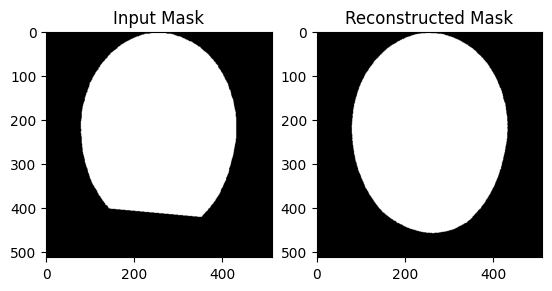

In [6]:
model.eval()
with torch.no_grad():
    img, sdf, weight, reg = next(iter(val_loader))
    p_sdf, p_reg = model(img.to(DEVICE))
    
    # Denormalize
    p_l, p_w = p_reg[0,0].item()*60, p_reg[0,1].item()*50
    a_l, a_w = reg[0,0].item()*60, reg[0,1].item()*50
    
    print(f"Pred: {p_l:.2f}mm x {p_w:.2f}mm | Actual: {a_l:.2f}mm x {a_w:.2f}mm")
    
    plt.subplot(1, 2, 1)
    plt.imshow(img[0,0].cpu(), cmap='gray')
    plt.title("Input Mask")
    
    plt.subplot(1, 2, 2)
    plt.imshow(p_sdf[0,0].cpu() > 0, cmap='gray')
    plt.title("Reconstructed Mask")
    plt.show()

In [7]:
from tqdm import tqdm

# Inference Configuration
INF_CSV_PATH    = r'cleaned_dataset\new_csv\inference_metadata_with_cutoffs.csv'
INF_INPUT_DIR   = r'cleaned_dataset\cut\inference_masks'
INF_OUTPUT_RECON_DIR = r'inference\reconstructed_masks'
INF_CSV_OUTPUT  = r'inference\inference_results.csv'
MODEL_PATH      = 'egg_geometry_model.pth'

os.makedirs(INF_OUTPUT_RECON_DIR, exist_ok=True)
os.makedirs('inference', exist_ok=True)

# Load inference CSV
df_inf = pd.read_csv(INF_CSV_PATH)

# Load model
inf_model = EggSDFModel().to(DEVICE)
inf_model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
inf_model.eval()

results = []
print(f"Inference started. Saving images to {INF_OUTPUT_RECON_DIR}...")

with torch.no_grad():
    for idx, row in tqdm(df_inf.iterrows(), total=len(df_inf)):
        img_name = row['image_path']
        input_path = os.path.join(INF_INPUT_DIR, img_name)

        img = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            print(f"Warning: could not read {input_path}, skipping.")
            continue

        img_t = torch.from_numpy(img).float().unsqueeze(0).unsqueeze(0).to(DEVICE) / 255.0
        p_sdf, p_reg = inf_model(img_t)

        # Denormalize
        pred_l = p_reg[0, 0].item() * 60.0
        pred_w = p_reg[0, 1].item() * 50.0

        # Save reconstructed mask (SDF > 0)
        recon_mask = (p_sdf[0, 0].cpu().numpy() > 0).astype(np.uint8) * 255
        recon_save_path = os.path.join(INF_OUTPUT_RECON_DIR, img_name.replace('.jpg', '.png'))
        os.makedirs(os.path.dirname(recon_save_path), exist_ok=True)  # handles subdirs in image_path
        cv2.imwrite(recon_save_path, recon_mask)

        results.append({
            'image_path': img_name,
            'pred_length_mm': round(pred_l, 2),
            'pred_width_mm': round(pred_w, 2),
            'reconstructed_mask_path': recon_save_path
        })

pd.DataFrame(results).to_csv(INF_CSV_OUTPUT, index=False)
print(f"\nDone! {len(results)}/{len(df_inf)} images processed.")
print(f"Results saved to {INF_CSV_OUTPUT}")

d:\Bach_Khoa\252-DATN\reconstruct\inovo\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\Bach_Khoa\252-DATN\reconstruct\inovo\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Inference started. Saving images to inference\reconstructed_masks...


100%|██████████| 4384/4384 [01:56<00:00, 37.77it/s]


Done! 4384/4384 images processed.
Results saved to inference\inference_results.csv
